# Netrunner Agenda Points Analysis

In [1]:
# Imports

import pandas as pd
import main as m
import regex as re
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import warnings
warnings.filterwarnings('ignore')

import notebook_companion as nc

Left adjust Markdown tables

In [2]:
%%html
<style>
    table {
        margin-left: 0 !important;
        float: left;
    }
</style>

## Wrangle

### Data Creation Methodology

* Develop a possibility matrix for all legal combinations of minimum deck size, use of the four card margin, agenda point total, and distribution of 1, 2, and 3 point agendas for corporation decks

* Store data as a dataframe where each row represents one combination of these features


* Calculate access threshold, the average number of unique random accesses a runner needs to steal 7 points worth of agendas and win the game, for each row using virtual experiments
    * Represent the corporation's deck my making a list containing a number of values equal to the testing deck’s deck size
        *  Agendas are represented with a number of one, two, and three values equal to the number of one, two, and three-point agendas in the deck
          
        *  The rest of the values are represented with zeros
     
          
    * Simulate a random access by choosing a value at random from the list and adding that value to the runners total score
        * Agendas give points equal to their value
      
        * Non-agendas give zero points
    * Simulate the accessed card being stolen, trashed (discarded from play), or otherwise avoided by removing that card from the list
 
    * Continue simulating random accesses until the runner has a score of 7 or more and count the number of accesses it took to reach this total
 
    * To ensure a large sample size and reduce statistical error repeat the experiment 100,000 times and get the average result
 
    * Round result to the nearest whole number for ease of discussion and communicability of result

### Let Them Dream

* Let Them Dream is a two-point agenda with an ability that reduces its vale by 1 if it is in the runner's score area effectively making it a two-point agenda for the corporation and a one-point agenda for the runner

* To measure the impact of Let Them Dream agendas on access threshold additional rows were added to simulate replacing ‘normal’ two-point agendas with maximum allowable number of ‘Let Them Dream’ agendas
    * For each row with one or more two-point agendas an additional row was added to the dataframe
        * for every two-point agenda in the new row the number of two-point agendas is reduced by one and the number of one-point agendas is increased by one, up to a maximum of 3
            * A maximum of 3 replacements are made because the maximum number of card copies (by title) that can be included in a deck is 3
            <br>  
* Limitation
    * This matrix only includes possibilities replacing the maximum number normal two-point agendas
      
        * It does not account for replacing less than the maximum (Example has 2 two-point agendas but only replaces one)
        
        * It does not account for replacements swapping 2 one-point agendas with 1 Let Them Dream
      
        * It does now account for replacements swapping 1 three-point agenda with 1 one-point agenda and 1 Let Them Dream
      
        * This limitation is largely due to oversight and will be corrected if I should return to this project for future iterations

### Final Dataframe
* 928 total rows
  
    * 496 rows representing all legal combinations of minimum deck size, use of the four card margin, agenda point total, and distribution of 1, 2, and 3 point agendas for corporation decks
      
    * 432 rows that simulate replacing ‘normal’ two-point agendas with maximum allowable number of ‘Let Them Dream’ agendas

### Data Dictionary

|Feature|Definition|
|---|---|
|deck_size| Total number of cards |
|agenda_points| Total value of all agenda points on agendas |
|agenda_count| Number of agendas in this build |
|one_point_agendas| Number of agendas with a value of 1 |
|two_point_agendas| Number of agendas with a value of 2 |
|three_point_agendas| Number of agendas with a value of 3 |
|ltd_count| Number of "Let Them Dream" agendas |
|access_threshold| Average number of unique cards a runner must access win the game |

In [3]:
# read in data
df, df_normal, df_ltd = nc.get_my_data()

In Netrunner a corporation deck must contain a total number of cards (deck size) and agenda points according to the following chart

This Dataset represents all possible variations of corporation decks with regard to max/min deck dize, agenda point total, and distribution of one, two, and three point agenda cards and inclution of 'Let them Dream' agendas. This data set was generated using values found in the standard card pool as of (April 21, 2026).

|Deck Size|Agenda Points|
|---|---|
|40 to 44 | 18 or 19 |
|45 to 49 | 20 or 21 |
|50 to 54 | 22 or 23 |

<br>
<br>
<br>
<br>
<br>



<br>
<br>

**Let them Dream** is an agenda worth two points for the corp, but only one point for the runner

* This card counts as a two point agenda when counting the total Agenda Points in a corporation deck
* This card is represented as a one-point agenda in Agenda Counts and when determining Average Accesses

**Average Accesses** was determined using digital experiments

* Method
    * Generate list representing agenda values of each card in the corporation's deck using zero to represent non-agenda cards
    * Choose a 'card' from the list at random for the runner to 'access'
    * Add the the value of the 'accessed' card to the runners total and remove the card from the list
    * Continue choosing new 'cards' until the runner has accessed 7 points worth of cards and note the number of accesses
    * Repeat the experiment 100_000 times and calculate the average number of accesses across all of the experiments


## Data Exploration

### Overview of Access Threshold 

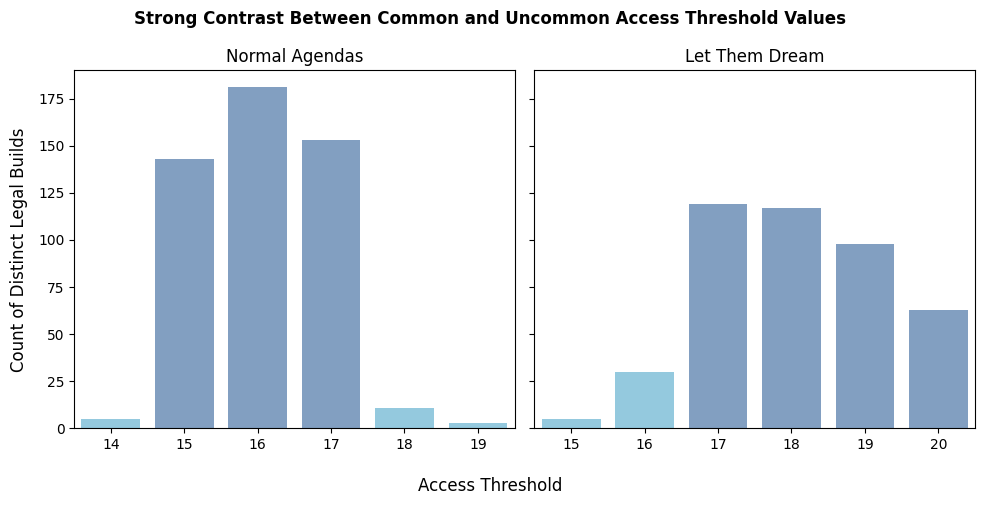

In [4]:
nc.get_my_thresholds(df_normal, df_ltd)

* The grand majority of normal agenda builds have an access threshold that ranges between 15 and 17

    * This indicates values outside the of majority ragee will only occur under precice conditions
    <br>
* The grand majority of Let Them Dream builds have an access threshold between 17 and 20

    * This indicates values lower than the majority range will only occur under precice conditions
    <br>
* The shift in majority range from 15-17 in normal builds to 17-20 in Let Them Dream builds indicates that replacing normal two-point agendas with Let Them Dream agendas could increase access threshold by 2-3 accesses

### How Does Agenda Density Influence Access Thereshold?
* In this study I define agenda density as the number of agenda points in a build relative to the total number of cards in that build
* I have calculated agenda density by dividing the number of agenda points in each build by the totaol number of cards in that build

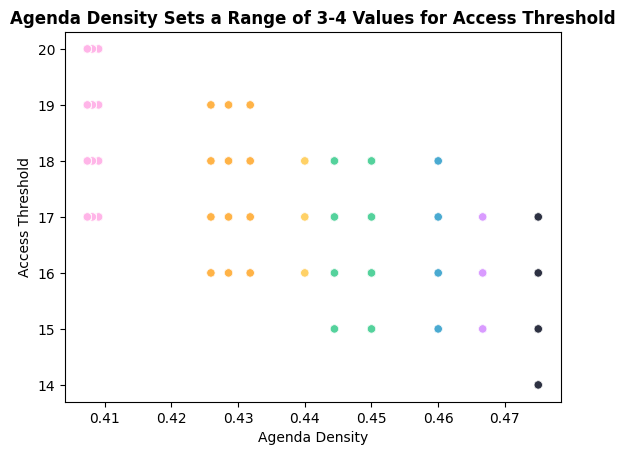

In [5]:
nc.get_my_density_chart(df)

* Agenda density has a negative relationship with access threshold setting a range of 3-4 possible values
* Values within that range are determined by other factors

## How Does Deck Size Influence Access Threshold?

### Corporation Deck Building Requirements 

* A minimum number of agenda points based on the total number of cards in the corporation's deck
    * This begins at 18 for a 40 card deck and incresing by 2 for every five additional cards
    * Player's may include 1 additional agenda point above the minimum if they choose (example a 40 card deck could include a total of 18 or 19 agenda points)
      
* Because the added cards have a lower agenda density than the original minimum corps can lower there agenda density by incresing thier deck size
* Because each minimum deck size has a '4 card mirgin' untill the next manditory agenda point increas it is common wisdom to add an extra 4 cards to the minimum when building a deck to decrese agenda density

### Minimum Deck Size

* The minimun deck size for a corporation deck is 40, 45, or 50 depending on the identity card chosen for the build

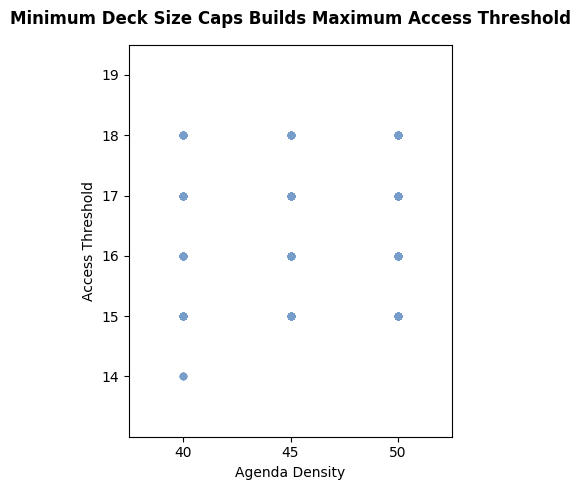

In [6]:
nc.get_min_deck_chart(df)

* Builds using the minimum deck size have an access threshold range that caps at 18
    * 2 less than the full possibility matrix
* There is a negligable difference between minimum deck sizes
    * The possibility of a particularly low access threshold does exist when using a 40 card build 

### 4 Card Margin
* Because the requiered agenda point total only increses with every 5th card added it is conventional wisdom to build corporation decks 4 cards over the minimum to reduce agenda density
* I am calling this the 4 card Margin

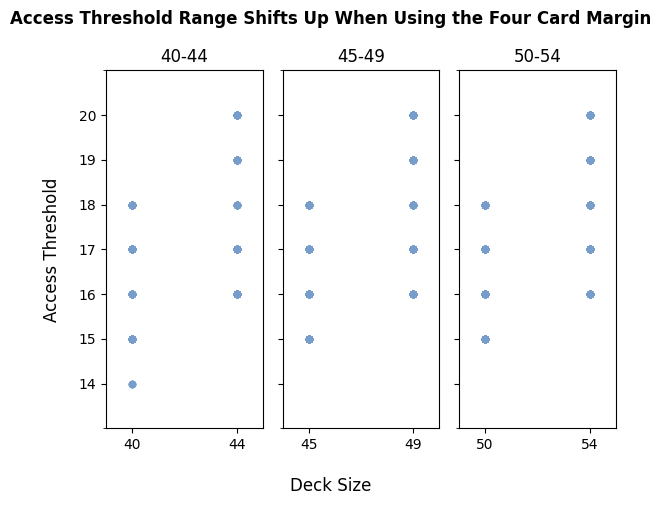

In [7]:
nc.get_margin_chart(df)

* Based on the shift in the access threshold range using the four card margin will raise a build's access threshold by 1-2 accesses

In [8]:
def plot_grid_by_list(df, values, filter_col, x_col, y_col,
                      ncols=4, nrows=2, figsize=(16,8), marker='o', s=20):
    """
    df: pandas DataFrame
    values: list of values to iterate through (one value per subplot)
    filter_col: column name to filter df by equality to each value
    x_col, y_col: columns to plot
    ncols, nrows: grid shape (default 4x2)
    """

    Values = [40,44,45,49,50,49,54]
    
    n_cols = 4
    n_rows = 2
    
    X_col = 'agenda_points'
    y_col = 'access_threshold'

    filter_col = 'deck_size'

    figsize = (16,8)
    
    total = ncols * nrows
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharex=False, sharey=True)
    
    axes = axes.flatten()

    for i in range(total):
        ax = axes[i]
        if i < len(values):
            val = values[i]
            sub = df[df[filter_col] == val]
            if not sub.empty:
                sub.plot.scatter(x=x_col, y=y_col, ax=ax, title=f"{filter_col}={val}", marker='o', s=s)
            else:
                ax.set_title(f"{filter_col}={val} (no data)")
                ax.set_xticks([])
                ax.set_yticks([])
        else:
            # blank any unused subplots
            ax.axis('off')

    plt.tight_layout()
    plt.show()


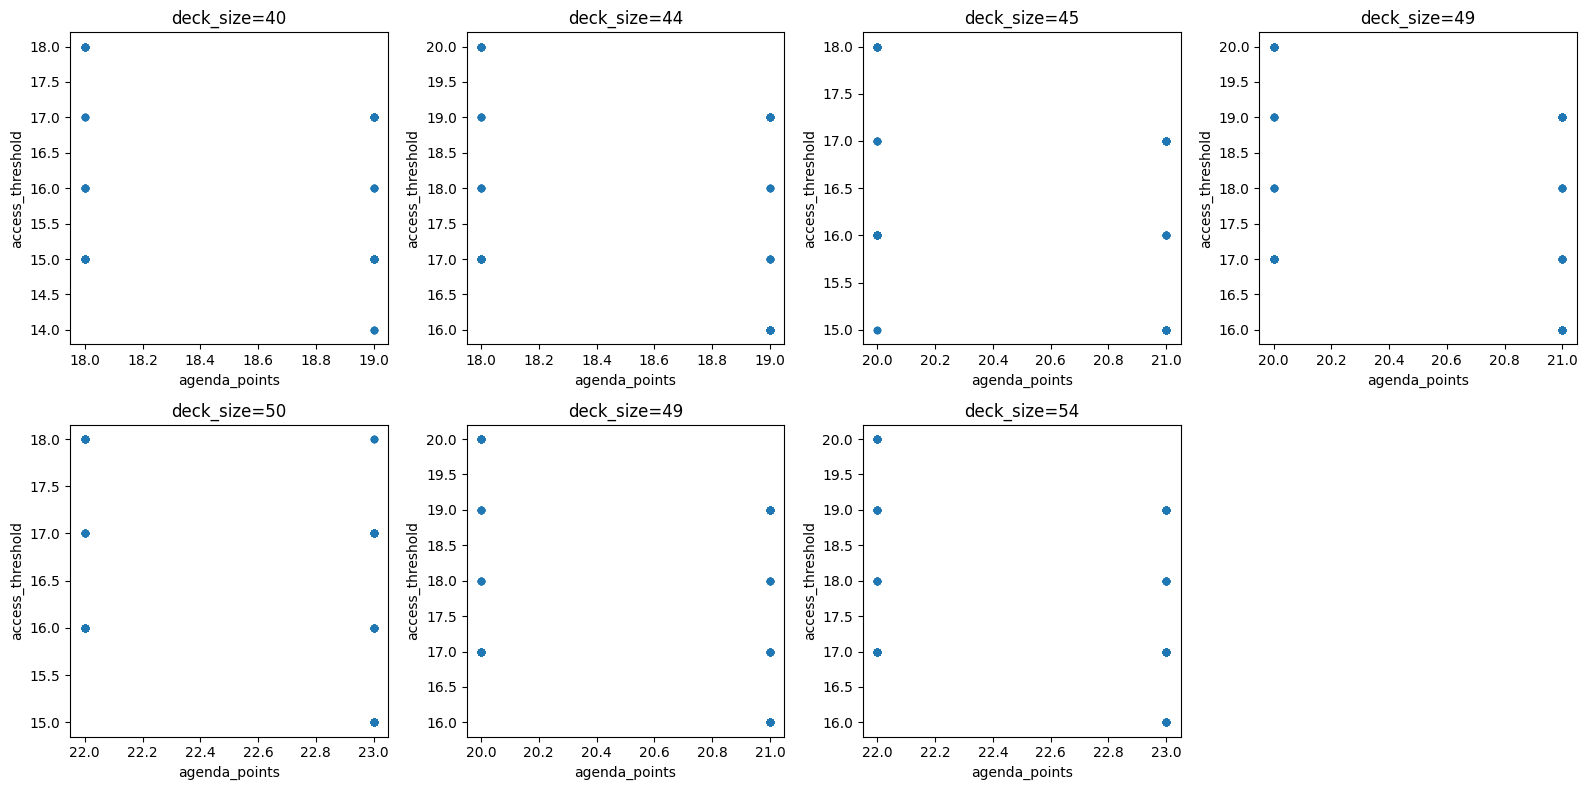

In [9]:
plot_grid_by_list(df, [40,44,45,49,50,49,54], 'deck_size', 'agenda_points', 'access_threshold',
                      ncols=4, nrows=2, figsize=(16,8), marker='o', s=20)

* The distribution of access thresholds shifts down by about 1 access when moving from the minimum to the maximum requiered agenda point total across all deck sizes 
* This suggests building to the minimum requiered agenda point total increses access threshold by 1

## Agenda Density Summary

* The minimum deck size enforced by corporation IDs has a negligible impact on access threshold
* Use of the 4 card margin will increase access threshold by 1-2 accesses
* Including the minimum number of agenda points for a given deck size increase access threshold by one as opposed to including the maximum

# Agenda Concentration

**The degree to which agenda points are concentrated in high point cards or spread out in lower point cards**

KeyError: 'average_accesses'

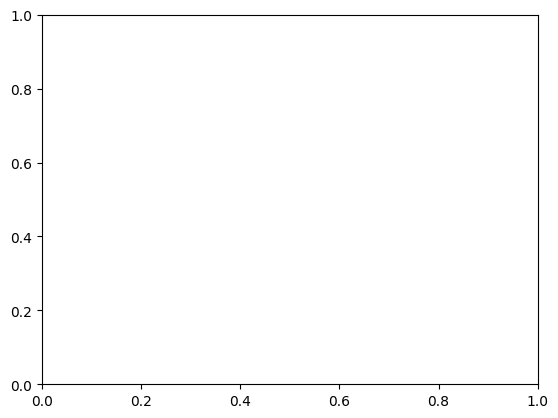

In [10]:
df_normal.plot.scatter(x='num_agendas', y='average_accesses', title='There is an Inverse Relationship Between Number of Normal Agendas and Average Required Accesses')

plt.tight_layout()
plt.show()

* When using normal agendas we can see some clear cutoffs for building a deck with the highest level access threshold
    * Example: A deck with an access threshold of 18 can contain no more than 11 agendas
* The impact of agenda count is negligable at middle threshold values  
    * Decks with a threshold value of 15-17 may contain almost any legal number of agendas
* There are some agenda counts that can produce a particualrly low access threshold (14) 
    * This suggests that the way in which agenda point are distrubuted among agenda cards influances access threshold

In [ ]:
df.columns

In [ ]:
df_normal.plot.scatter(x='threes', y='average_accesses', title='Team Three Star')

plt.tight_layout()
plt.show()

* The number of three-point agendas is highly variable in builds with a moderate access thresholds
* At extreme values builds with a higher number of three-point agendas have a higher access threshold and vice versa 
    * The exception to this rule are builds that contain only two-point agendas (See the chart below for details)

**Dataframe of all corp builds with zero three-point agendas and an access threshold of 18**

In [ ]:
# get dataframe of all corp builds with zero three-point agendas and an access threshold of 18
df_twos = df_normal[(df_normal.average_accesses == 18) & (df_normal.threes == 0)]

df_twos[['agenda_type', 'deck_size', 'agenda_points', 'agenda_counts', 'average_accesses']]

In [ ]:
df.columns

In [ ]:
df_normal.plot.scatter(x='ones', y='average_accesses', title='Team one Star')

plt.tight_layout()
plt.show()

* The number of one-point agendas is highly variable in builds with a moderate access thresholds
* At extreme values builds with a lower number of one-point agendas have a higher access threshold and vice versa 
    * The exception to this rule is a build that uses the lowst possible deck size and the highest possible agenda point count this is the likely explination for this anomally (See the chart below for details) 

**Dataframe of all corp builds with zero one-point agendas and an access threshold of 14**

In [ ]:
# get dataframe of all corp builds with zero one-point agendas and an access threshold of 14

df_ones = df_normal[(df_normal.average_accesses == 14) & (df_normal.ones == 0)]

df_ones[['agenda_type', 'deck_size', 'agenda_points', 'agenda_counts', 'average_accesses']]

## Agenda Concentration

* Agenda count (Normal) has a large degree of veriability at thresholds 15-17, at more extreme values we see a negative relationship between agenda count and access threshold with clear cutoff points for agenda count allowable to produce a given access threshold

* Three-point agenda count (Normal) has a large degree of veriability at thresholds 15-17, at more extreme values we see a positive relationship between Three-point agenda count and access threshold with clear cutoff points for the required three-point agenda count needed to produce a given access threshold

* One-point agenda count (Normal) has a large degree of veriability at thresholds 15-17, at more extreme values we see a negative relationship between agenda count and access threshold with clear cutoff points for agenda count allowable to produce an access thresholds above 17


In [ ]:
df_normal['is'] = df.agenda_counts == '[3, 5, 0]'

In [ ]:
df_normal[df.agenda_counts == '[3, 5, 0]']

In [ ]:
def plot_grid_by_list(df, values, filter_col, x_col, y_col,
                      ncols=4, nrows=2, figsize=(16,8), marker='o', s=20):
    """
    df: pandas DataFrame
    values: list of values to iterate through (one value per subplot)
    filter_col: column name to filter df by equality to each value
    x_col, y_col: columns to plot
    ncols, nrows: grid shape (default 4x2)
    """

In [ ]:
plot_grid_by_list(df_normal, [True, False], 'is_350', 'agenda_points', 'average_accesses',
                      ncols=4, nrows=2, figsize=(16,8), marker='o', s=20)

In [ ]:
df.plot.scatter(x='let_them_dream_count', y='average_accesses', title='Let Them Dream')

plt.tight_layout()
plt.show()

* Replacing one or two normal agendas with Let Them Dream agendas will increase the access threshold by about 1 point each capping at 19
* Replacing a third normal agenda will increase the access threshold by 1
* This shows about a one point increse in access threshold per Let Them Dream in the Corp Deck

## Let Them Dream

* Replacing a normal two-point agenda with a Let Them Dream agenda will raise a build’s access threshold by about 1 per agenda replaced. This is likely due to lowering the total number of agenda points the runner can steal by 1 per replaced agenda. 


## Summary and Conclusions

* Access thresholds across all possible builds have a range of 14 to 20 meaning that deck building decisions have a 6 access influence on access threshold
* Minimum deck size has a negligible effect on access threshold, however Including the 4 card in the margin between an IDs minimum deck size and the size at which the corp’s required agenda point total would increase increases access threshold by 1-2 accesses 
* Access thresholds in builds using the minimum agenda point total for its deck size are 1 access higher than builds using the maximum   
* Agenda density has a negative influence on access threshold
* Builds with a higher concentration of agenda points have a higher access thresholds
* Builds that include Let Them Dream agendas have access thresholds that are about 1 access higher for every normal two-point agenda replaced by a let them dream
* It occurs to me that I did not account for situations in which pairs of one point agendas are replaced by one let them dream agenda or situations in which one three point agenda is replaced by a one-point agenda and a Let Them Dream Agenda
    * In the former case I estimate a 1-2 access increase in access threshold, per replacement, due to the increase in agenda concentration (Two agendas replaced by one) and lowering of the stealable agenda point total by one. 
    * In the latter I estimate a 0-1 access increase in access threshold, per replacement,  due to the the decreases agenda concentration (one agenda swapping for two) mitigating the impact of lowering stealable agenda point total by one


## Recommendations

* Always use the four card margin, The increased access threshold as well as the resources granted by those four cards will outweigh the loss in consistency caused by the addition of those four cards
* Almost always build to the minimum number of agenda points for your deck size this will increase you access threshold by one, so do this unless you need access to a specific card and cannot otherwise fit it into your build
* Strongly consider using higher value agenda cards for your build. Your first priority in deck building should be deck synergy (how well the abilities on your cards work together). However, if you find that multiple agenda cards work just as well prioritise agendas with higher values
* Strongly consider using Let Them Dream agendas in your build. The major benefit to this card is that it lowers the number of agenda points the runner can steal by 1 per inclusion increasing a deck’s access threshold by 1-2 accesses per card included (depending on what’s being replaced). This combined with the agenda management included in its card ability makes it an auto include in builds that can cover the inv=fluance cost and don’t require an agenda suite that prohibits its use. 


In [ ]:
import matplotlib.pyplot as plt

df_small = df_normal[df['deck_size'].between(40,44)]
df_mid = df_normal[df.deck_size.between(45,49)]
df_lg = df_normal[df.deck_size.between(50,54)]

fig, axes = plt.subplots(ncols=3, figsize=(10,5))

# Added xlabel='' and ylabel='' to each scatter plot to remove individual labels
df_small.plot.scatter(x='deck_size', y='access_threshold', title='40-44', xlabel='', ylabel='', ax=axes[0])
df_mid.plot.scatter(x='deck_size', y='access_threshold', title='45-49', xlabel='', ylabel='', ax=axes[1])
df_lg.plot.scatter(x='deck_size', y='access_threshold', title='50-54', xlabel='', ylabel='', ax=axes[2])

fig.suptitle('This is My Super Title', fontsize=16, fontweight='bold')

fig.supxlabel('Deck Size')
fig.supylabel('Access Threshold')

fig.align_ylabels()

plt.tight_layout()
plt.show()